## Instructions {-}

1. You may talk to a friend, discuss the questions and potential directions for solving them. However, you need to write your own solutions and code separately, and not as a group activity. 

2. Write your code in the **Code cells** and your answers in the **Markdown cells** of the Jupyter notebook. Ensure that the solution is written neatly enough to for the graders to understand and follow.

3. Use [Quarto](https://quarto.org/docs/output-formats/html-basics.html) to render the **.ipynb** file as HTML. You will need to open the command prompt, navigate to the directory containing the file, and use the command: `quarto render filename.ipynb --to html`. Submit the HTML file.

4. The assignment is worth 100 points, and is due on **18th October 2025 at 11:59 pm**. 

5. **Five points are properly formatting the assignment**. The breakdown is as follows:
    - Must be an HTML file rendered using Quarto **(1 point)**. *If you have a Quarto issue, you must mention the issue & quote the error you get when rendering using Quarto in the comments section of Canvas, and submit the ipynb file.* 
    - No name can be written on the assignment, nor can there be any indicator of the student’s identity—e.g. printouts of the working directory should not be included in the final submission.  **(1 point)**
    - There aren’t excessively long outputs of extraneous information (e.g. no printouts of entire data frames without good reason, there aren’t long printouts of which iteration a loop is on, there aren’t long sections of commented-out code, etc.) **(1 point)**
    - Final answers to each question are written in the Markdown cells. **(1 point)**
    - There is no piece of unnecessary / redundant code, and no unnecessary / redundant text. **(1 point)**

6.  The maximum possible score in the assigment is 100  + 15 (bonus task) + 5 (AI usage disclosure)= 120 out of 100.

## Objective

- **Reinforce Knowledge of Gradient Descent:** Apply your understanding of gradient descent to classification problems by implementing logistic regression and softmax regression from scratch.
- **Hands-on Implementation:** Build classification models manually to gain deeper insights into their mathematical foundations and working principles.
- **Explore Customization Options:** Learn how implementing models from scratch allows you to:
  - Adjust and optimize model parameters for specific requirements.
  - Add features or constraints that might not be possible with standard libraries.
- **Compare with Pre-built Models:** Use scikit-learn’s logistic regression as a baseline to evaluate the performance and efficiency of your custom implementation. This will help you understand when to use custom models and when to leverage pre-built ones.
- **Prepare for Real-world Scenarios:** Understand the scenarios where off-the-shelf models are not sufficient, allowing you to confidently tackle complex machine learning problems and create novel solutions.


In [1179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
import time

## Refreshing the Foundations: Sigmoid & Logistic Regression

### Why Logistic Regression? The Classification Challenge

<p align="center">
  <img src="images/image-96.webp" alt="Logistic Cost Function" width="400">
</p>

**The Problem**: Linear regression gives us $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$, but for classification:

- **Linear regression outputs**: Any real number (-∞ to +∞)
- **Classification needs**: Probabilities between 0 and 1
- **Binary targets**: $y \in \{0, 1\}$ (e.g., Disease/No Disease, Spam/Not Spam)

**The Solution**: Transform linear outputs into probabilities using the **sigmoid function**, creating a model that outputs meaningful probabilities for binary classification decisions.

**Real-World Context**: In this assignment, you'll predict heart disease risk where:
- **Input**: Patient medical data (age, cholesterol, chest pain type, etc.)
- **Output**: Probability of heart disease (0 = healthy, 1 = disease)
- **Goal**: Build a model doctors can trust for medical decision-making


### The Sigmoid Function: Mathematical Bridge to Probabilities

**Mathematical Definition:**
$$g(z) = \frac{1}{1 + e^{-z}} \tag{1}$$

**What This Function Does:**
- **Input $z$**: Any real number (-∞ to +∞) from linear model
- **Output $g(z)$**: Always between 0 and 1 (perfect for probabilities!)
- **S-shaped curve**: Smooth transition from 0 to 1

**Key Properties:**
- **$g(0) = 0.5$**: Neutral prediction (equal probability of both classes)
- **$g(z) \to 1$** as $z \to +\infty$: Strong positive evidence → high probability  
- **$g(z) \to 0$** as $z \to -\infty$: Strong negative evidence → low probability
- **Always smooth**: No sudden jumps, making it perfect for gradient descent optimization

**Practical Interpretation:**
In logistic regression, $z = \mathbf{w} \cdot \mathbf{x} + b$ represents the "log-odds" or "logit":
- **Positive $z$**: Model leans toward class 1 (e.g., "has disease")
- **Negative $z$**: Model leans toward class 0 (e.g., "healthy")  
- **Magnitude of $|z|$**: Confidence level of the prediction

**Implementation Note**: NumPy's [`exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) function handles vectorized computation efficiently, but requires careful numerical handling to avoid overflow (which you'll implement!).

### Logistic Regression: Model
<img align="left" src="./images/C1_W3_LogisticRegression_right.png"     style=" width:300px; padding: 10px; " > A logistic regression model applies the sigmoid to the familiar linear regression model as shown below:

$$ 
f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b ) \tag{2} 
$$ 

  where

  $$
  g(z) = \frac{1}{1+e^{-z}}\tag{3}
  $$

### Logistic Regression: Loss Function

Logistic Regression uses a loss function more suited to the task of categorization where the target is 0 or 1 rather than any number. 

>**Definition Note:**   In this course, these definitions are used:  
**Loss** is a measure of the difference of a single example to its target value while the  
**Cost** is a measure of the losses over the training set


This is defined: 
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is:

\begin{equation}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
    - \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=1$}\\
    - \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=0$}
  \end{cases}
\end{equation}


*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value.

*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot\mathbf{x}^{(i)}+b)$ where function $g$ is the sigmoid function.

The defining feature of this loss function is the fact that it uses two separate curves. One for the case when the target is zero or ($y=0$) and another for when the target is one ($y=1$). Combined, these curves provide the behavior useful for a loss function, namely, being zero when the prediction matches the target and rapidly increasing in value as the prediction differs from the target. Consider the curves below:

<div style="text-align: center;">
    <img src=https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTIyEcDUIGx9kLDohkOyjq8X2OkQZbxLoVW3JyEefVtog&s alt="Description of image" width="400"/>
</div>

Combined, the curves are similar to the quadratic curve of the squared error loss. Note, the x-axis is $f_{\mathbf{w},b}$ which is the output of a sigmoid. The sigmoid output is strictly between 0 and 1.

The loss function above can be rewritten to be easier to implement.
    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)$$
  
This is a rather formidable-looking equation. It is less daunting when you consider $y^{(i)}$ can have only two values, 0 and 1. One can then consider the equation in two pieces:  
when $ y^{(i)} = 0$, the left-hand term is eliminated:
$$
\begin{align}
loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), 0) &= (-(0) \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - 0\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \\
&= -\log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
\end{align}
$$
and when $ y^{(i)} = 1$, the right-hand term is eliminated:
$$
\begin{align}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), 1) &=  (-(1) \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - 1\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\\
  &=  -\log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
\end{align}
$$

**Why This Loss Function Works:**
1. **Probabilistic Foundation**: Derived from maximum likelihood estimation
2. **Convex Optimization**: Guarantees unique global minimum (perfect for gradient descent)
3. **Penalizes Confidence**: Wrong confident predictions get heavily penalized
4. **Smooth Gradients**: Enables stable gradient descent convergence

**Connection to Your Implementation**: This loss function is exactly what you'll implement in Task 1, with the addition of L2 regularization to prevent overfitting on the heart disease dataset.

### Logistic Regression: Cost Function (Training Objective)

**From Individual Loss to Overall Cost:**

The **cost function** aggregates individual losses across all training examples to create our optimization objective:

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

Where the individual **loss** for each example is:

$$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$

**The Complete Model Pipeline:**
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$

**Optimization Goal**: Find weights $\mathbf{w}$ and bias $b$ that minimize $J(\mathbf{w},b)$ using **gradient descent**.


## Bridge to Implementation: What You'll Build

### Your Assignment Journey:
1. **Task 1**: Implement cost function with L2 regularization → **20 points**  
2. **Task 2**: Apply to heart disease dataset with preprocessing → **15 points**  
3. **Task 3**: Experiment with regularization strength (λ) → **20 points**  
4. **Task 4**: Benchmark against scikit-learn LogisticRegression → **20 points**  
5. **Task 5**: Explore the `tol` parameter in gradient descent–based models → **15 points**  
6. **Task 6**: Summarize key learnings and insights → **5 points** 

### ⭐ Bonus Task  
Extend your L2-regularized logistic regression by adding a **`tol` stopping criterion**, and compare its behavior with scikit-learn’s implementation -> **15 points**
   
### Key Implementation Challenges You'll Solve:

- **Numerical Stability**: Prevent `log(0)` errors that break gradient descent
- **Vectorization**: Implement efficient matrix operations for real-world performance
- **Regularization**: Add L2 penalty to prevent overfitting on complex medical data
- **Gradient Computation**: Derive and implement the gradient for weight updates
- **Convergence Monitoring**: Track training progress and detect overfitting

### Real-World Impact:
Your implementation will predict heart disease risk using patient data—a model that could potentially assist medical professionals in making life-saving decisions. The mathematical rigor you develop here translates directly to production ML systems used in healthcare, finance, and technology.
 

## Task 1: Implementing L2 Regularized Logistic Regression with Vectorized Gradient Descent **(20 points)**

###  **Objective**
Implement a complete L2 regularized (Ridge) logistic regression algorithm from scratch using vectorized operations to prevent overfitting in binary classification problems.

### 📋 **Implementation Requirements**

#### **Main Function Signature**
Your implementation should create a main training function that takes these inputs:

- **X_train** (ndarray): Training feature matrix (m × n) - **Note**: Should include bias column of ones as first column
- **y_train** (ndarray): Training labels (m × 1) 
- **X_test** (ndarray): Test feature matrix for monitoring overfitting - **Note**: Should include bias column  
- **y_test** (ndarray): Test labels for performance tracking
- **w_in** (ndarray): Initial weights ((n+1) × 1) - **Includes bias weight as first element**
- **alpha** (float): Learning rate (typically 0.001 - 0.01)
- **num_iters** (int): Number of training iterations
- **lambda_reg** (float): L2 regularization strength (λ ≥ 0)

#### **Expected Outputs**
- **Optimized parameters**: Final weights after training
- **Training cost history**: Cost values at each iteration on training data
- **Test cost history**: Cost values at each iteration on test data (for overfitting analysis)

### **Implementation Structure**

#### **Step 1: Cost Function with L2 Regularization**
```python
def compute_cost_logistic_ridge(X, y, w, lambda_reg):
```
**Mathematical Formula:**
$$J(w) = \frac{1}{m}\sum_{i=1}^{m} \left[ -y^{(i)} \log(h_w(x^{(i)})) - (1-y^{(i)}) \log(1-h_w(x^{(i)})) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

Where $h_w(x) = \sigma(w^T x)$ and $\sigma(z) = \frac{1}{1+e^{-z}}$

**Key Implementation Notes:**

- Use vectorized operations for efficiency
- **Bias handling**: Don't regularize the bias term (w[0]) - exclude from L2 penalty
- **Data preparation**: Add column of ones to X matrices for bias term
- Handle numerical stability with log functions

**Why Numerical Stability Matters:**

- **When h = 0**: `log(0) = -∞` → **NaN in cost calculations**
- **When h = 1**: `log(1-h) = log(0) = -∞` → **NaN in cost calculations**  
- **When it occurs**: Sigmoid outputs extreme values (overconfident predictions)
- **Consequence**: Entire gradient descent breaks due to NaN propagation

   **Practical Example:**
   ```python
   # Without clipping - BREAKS!
   h = np.array([0.0, 0.5, 1.0])  # Sigmoid predictions
   cost = -np.log(h)  # Returns: [inf, 0.693, 0.0]
   # ↑ inf values propagate to gradients → NaN → training failure

   # With clipping - WORKS!
   h_safe = np.clip(h, 1e-15, 1-1e-15)  # Safe range: [1e-15, 1-1e-15]
   cost = -np.log(h_safe)  # Returns: [34.54, 0.693, 34.54]  
   # ↑ All finite values → stable gradients → successful training
   ```

**Professional Tip**: All major ML libraries (TensorFlow, PyTorch, sklearn) use similar clipping internally!

#### **Step 2: Gradient Computation with L2 Regularization**
```python
def compute_gradient_logistic_ridge(X, y, w, lambda_reg):
```
**Mathematical Formula:**
$$\frac{\partial J}{\partial w_j} = \frac{1}{m} X^T (\sigma(Xw) - y) + \frac{\lambda}{m} w_j \quad \text{(for } j > 0\text{)}$$
$$\frac{\partial J}{\partial w_0} = \frac{1}{m} X^T (\sigma(Xw) - y) \quad \text{(bias term, no regularization)}$$

**Implementation Note**: The gradient vector should be same shape as w_in ((n+1) × 1), where the first element corresponds to the bias term gradient (no regularization) and remaining elements include the L2 regularization term.

#### **Step 3: Gradient Descent Algorithm**
```python
def gradient_descent_logistic_ridge(X_train, y_train, X_test, y_test, w_in, alpha, num_iters, lambda_reg):
```

#### 💡 **Implementation Tips**

1. **Bias Term Setup**: 
   - Add column of ones as **first column** of X matrices: `X = np.column_stack([np.ones(m), X_features])`
   - Initialize w_in with shape (n+1, 1) where w[0] is bias, w[1:] are feature weights
2. **Vectorization**: Use matrix operations instead of loops for efficiency
3. **Numerical Stability**: 
   - Clip extreme values in sigmoid to prevent overflow
   - Use `np.clip(predictions, 1e-15, 1-1e-15)` for log calculations
4. **Regularization Implementation**: 
   - Create regularization vector: `reg_term = np.copy(w); reg_term[0] = 0` (exclude bias)
   - Add to gradient: `gradient + (lambda_reg/m) * reg_term`
5. **Monitoring**: Track both training and test costs to observe overfitting


#### ✅ **Validation Checklist**
- [ ] Cost decreases monotonically during training
- [ ] Implementation uses vectorized operations (no explicit loops over samples)
- [ ] Regularization term correctly excludes bias
- [ ] Both training and test costs are tracked
- [ ] Function handles edge cases (very small/large predictions)


In [1180]:
#cost function

def compute_cost_logistic_ridge(X, y, w, lambda_reg):

    m = X.shape[0] #get number of rows
    
    z = X @ w
    h_w = 1 / (1 + np.exp(-z)) #perform sigmoid function
    h_w_safe = np.clip(h_w, 1e-15, 1-1e-15) #clip h to prevent log errors
    cost = (1 / m) * ((-y @ np.log(h_w_safe)) - ((1 - y) @ np.log(1 - h_w_safe)))

    reg_term = (lambda_reg / (2*m)) * np.sum(w[1:]**2) #add regularization term to all but b
    reg_cost = cost + reg_term

    return reg_cost

In [1181]:
#gradient compute function
def compute_gradient_logistic_ridge(X, y, w, lambda_reg):

    m = X.shape[0] #get number of rows

    z = X @ w
    sigma = 1 / (1 + np.exp(-z)) #sigmoid function
    
    dj_dw = X.T @ (sigma-y) / m #get typical gradient

    reg_term = lambda_reg/m * w[1:]
    reg_term = np.concatenate(([0], reg_term))

    dj_dw_reg = dj_dw + reg_term #add regularization term to all but b
    
    return dj_dw_reg

In [1182]:
#gradient descent
def gradient_descent_logistic_ridge(X_train, y_train, X_test, y_test, w_in, alpha, num_iters, lambda_reg):

    #create storage objects
    J_history = []
    test_J_history = []

    w = copy.deepcopy(w_in) #copy w

    for i in range(num_iters):
        gradient = compute_gradient_logistic_ridge(X_train, y_train, w, lambda_reg) #compute gradient
        w = w - (alpha*gradient) #update gradient
        cost = compute_cost_logistic_ridge(X_train, y_train, w, lambda_reg) #train cost
        J_history.append(cost)
        test_cost = compute_cost_logistic_ridge(X_test, y_test, w, lambda_reg) #test cost
        test_J_history.append(test_cost)
        if i % 5000 == 0:
            print(f"For iteration {i+1}/{num_iters}, the training cost is {cost}.")
            print(f"For iteration {i+1}/{num_iters}, the test cost is {test_cost}.")
    
    return w, J_history, test_J_history


## Task 2: Apply your implementation on a real dataset **(15 points)**

### **Objective**
Apply your L2 regularized logistic regression implementation to predict heart disease using a real medical dataset, demonstrating proper data preprocessing, model training, and performance visualization.

### **Dataset Overview** 
The **heart_disease_classification.csv** contains medical data for heart disease prediction with:

- **Target**: Binary classification (0=No Disease, 1=Disease)  
- **Features**: Mix of numerical (age, cholesterol) and categorical (chest pain type, slope)
- **Challenge**: Categorical variables need proper encoding for your algorithm

### 📋 **Step-by-Step Implementation Guide**

#### **Step 1: Data Loading and Initial Exploration**

In this step, you will begin by **importing the dataset into your working environment** (e.g., using `pandas.read_csv()` for CSV files). After successfully loading the data, perform some **basic exploratory checks** to understand its structure and contents. This includes:

- Displaying the **first few rows** of the dataset with `.head()` to get a sense of the data format  
- Checking the **dimensions** of the dataset with `.shape` to see how many rows and columns are available  
- Inspecting the **column names and data types** with `.info()` to identify numerical, categorical, and datetime features  
- Reviewing **summary statistics** with `.describe()` to quickly understand ranges, averages, and distributions of numeric columns  

This step ensures that you have properly loaded the dataset and gained a **high-level understanding of its characteristics**, which is essential before moving into deeper transformation, or modeling tasks.

In [1183]:
data = pd.read_csv('../instructor/Assignment 1/heart_disease_classification.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [1184]:
data.shape

(303, 14)

In [1185]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [1186]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


#### **Step 2: Data Shuffling and Feature-Target Separation (*random_state=0*)**

After loading and exploring the dataset, the next step is to **prepare it for modeling**. This involves two tasks:

1. **Shuffling the data**
   - Many real-world datasets, especially in domains like **medicine**, are collected in sequential order (e.g., sorted by collection date, patient ID, or clinical visit number).  
   - If you split the dataset without shuffling, the training set may contain only earlier cases and the test set may contain only later ones. This can introduce **temporal or ID-based bias** and reduce the model’s ability to generalize.  
   - Shuffling ensures that the **distribution of samples is random**, giving both training and test sets a representative mix of patients and outcomes.  
   - We use `random_state=0` to make the shuffle **reproducible**, so everyone gets the same randomized order.  

2. **Separating features and target**
   - Define the **target variable** (the outcome you want to predict, e.g., disease status, biomarker level, or treatment response).  
   - Select the **features** (independent variables, such as patient demographics, lab values, or imaging-derived metrics).  
   - Split the dataset into:  
     - `X` → the **feature matrix** (all input variables except the target)  
     - `y` → the **target vector** (the label or response variable)  

In [1187]:
#shuffle data
shuffled_data = data.sample(frac=1, random_state=0).reset_index(drop=True)

#split data
y = shuffled_data.target
X = shuffled_data.iloc[:, :13]

#### **Step 3: Train–Test Split (random_state=42) and Feature Scaling**

Once the dataset is shuffled and the features (`X`) and target (`y`) are separated, the next step is to **divide the data into training and testing subsets**.  

- **Training set**: Used to fit the model (learn the patterns from the data).  
- **Test set**: Held back to evaluate how well the model generalizes to unseen data.  

We typically use **80% of the data for training** and **20% for testing**, though this ratio can be adjusted based on dataset size and problem context.  

To ensure reproducibility, we specify `random_state=42` when performing the split.  

##### ✅ Why split the data?

- Prevents **overfitting** by ensuring the model is evaluated on unseen data.  
- Mimics a real-world scenario where the model encounters new patient cases.  
- Provides an unbiased estimate of model performance. 

##### ✅ Why scaling matters
- Features may be measured on very different scales (e.g., **age** ranges 20–80, while **cholesterol** may range 100–600).  
- Algorithms that use **gradient descent** (e.g., logistic regression, neural networks) can converge slowly or get stuck if features are not scaled properly.  
- Scaling puts all features on a **comparable range**, improving both **training stability** and **model performance**. 

**Important Notes**:  

- Use `fit_transform()` **only on the training set** so the scaler does not "see" information from the test set (**avoiding data leakage**).  
- Apply the fitted scaler to the **test set** using `transform()`.


I modified the order of the steps to go data split, then encoding categorical variables, then scaling the data, based on professor's instructions to use this order on ed discussion. See under step 4 for all three steps combined. 

#### **Step 4: Categorical Variable Encoding**

The dataset contains **categorical variables** that must be converted into numerical form before modeling. Most machine learning algorithms cannot directly handle categorical text values, so we use **binary (dummy) encoding**.


**Required Encoding for These Columns:**
- **`cp`** (Chest Pain Type): Convert into binary dummy variables  
- **`thal`** (Thalassemia): Convert into binary dummy variables  
- **`slope`** (ST Slope): Convert into binary dummy variables  


##### ✅ Why Encode?
- Machine learning algorithms work with **numbers**, not text labels.  
- Encoding categorical variables as dummy variables prevents the model from assuming an **ordinal relationship** between categories (e.g., category "3" is not “greater than” category "1").  
- This ensures that the algorithm treats categories as **independent groups**.  



##### Example (using `pandas.get_dummies`)

```python
import pandas as pd

# Encode categorical variables into dummy variables
df_encoded = pd.get_dummies(df, columns=['cp', 'thal', 'slope'], drop_first=True)

# View the new columns
df_encoded.head()
```
Here:

- `pd.get_dummies()` automatically creates binary (0/1) columns for each category.

- `drop_first=True` avoids multicollinearity by dropping one category from each variable as the reference group.


In [1188]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [1189]:
#encode categoricals
encoder = OneHotEncoder(handle_unknown="ignore", drop="first", dtype=int)
encoder.fit(X_train[['cp', 'thal', 'slope']])

#get transformed values
X_train_encoded_df = pd.DataFrame(
    encoder.transform(X_train[['cp', 'thal', 'slope']]).toarray(),
    columns=encoder.get_feature_names_out(['cp', 'thal', 'slope']),
    index=X_train.index)

X_test_encoded_df = pd.DataFrame(
    encoder.transform(X_test[['cp', 'thal', 'slope']]).toarray(),
    columns=encoder.get_feature_names_out(['cp', 'thal', 'slope']),
    index=X_test.index)

#replace categorical values with binary
X_train_encoded = pd.concat([X_train.drop(['cp', 'thal', 'slope'], axis=1), X_train_encoded_df], axis=1)
X_test_encoded = pd.concat([X_test.drop(['cp', 'thal', 'slope'], axis=1), X_test_encoded_df], axis=1)

X_train_encoded.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
132,40,1,152,223,0,1,181,0,0.0,0,0,0,0,0,0,1,0,1
202,53,1,142,226,0,0,111,1,0.0,0,0,0,0,0,0,1,0,1
196,54,0,135,304,1,1,170,0,0.0,0,0,1,0,0,1,0,0,1
75,51,1,110,175,0,1,123,0,0.6,0,0,1,0,0,1,0,0,1
176,63,0,150,407,0,0,154,0,4.0,3,0,0,0,0,0,1,1,0


In [1190]:

#scale data except dummies
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = copy.deepcopy(X_train)
X_test_scaled = copy.deepcopy(X_test)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled= pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

#### **Step 5: Model Training and Hyperparameter Selection**

With the training and test sets prepared, the next step is to **train the model**. This involves selecting appropriate **hyperparameters** that control how the algorithm learns.  


##### ✅ Key Considerations
- **Learning Rate (`α`)**: Controls the step size during gradient descent updates.  
  - Too large → the algorithm may diverge.  
  - Too small → convergence becomes very slow.  

- **Number of Iterations / Epochs**: Determines how many times the algorithm goes through the training data.  
  - Choose enough iterations for convergence, but avoid unnecessary computation.  

- **Regularization (if applicable)**: Prevents overfitting by penalizing large weights.  

#####  Practical Setup
- Initialize parameters (`w_in`).  
- Select a reasonable learning rate (`alpha`).  
- Choose the number of iterations (`num_iters`).  
- Set a regularization strength (`lambda_reg`).  

As long as the model **converges stably**, your hyperparameters are acceptable.  


In [1191]:
#add ones column to train
m = X_train_scaled.shape[0]
ones_column = np.ones((m, 1))
X_train_scaled_ones = np.c_[ones_column, X_train_scaled]

#add ones column to test
test_m = X_test_scaled.shape[0]
test_ones_column = np.ones((test_m, 1))
X_test_scaled_ones = np.c_[test_ones_column, X_test_scaled]

#create initial x
n = X_train_scaled_ones.shape[1] 
w_in = np.zeros(n)

In [1192]:
#set hyperparameters
alpha = 0.01  
num_iters = 60000
lambda_l2 = 0.01

#perform gradient descent
l1_w, J_history, test_J_history = gradient_descent_logistic_ridge(X_train_scaled_ones, y_train, X_test_scaled_ones, y_test, w_in, alpha, num_iters, lambda_l2)
print(f"w found by gradient descent with L1 regularization: {l1_w} ")

For iteration 1/60000, the training cost is 0.6896626919138368.
For iteration 1/60000, the test cost is 0.6902435904003639.
For iteration 5001/60000, the training cost is 0.3333458067971723.
For iteration 5001/60000, the test cost is 0.4383456834742863.
For iteration 10001/60000, the training cost is 0.3331811893842384.
For iteration 10001/60000, the test cost is 0.442759191064308.
For iteration 15001/60000, the training cost is 0.33317846327175377.
For iteration 15001/60000, the test cost is 0.44331952270753966.
For iteration 20001/60000, the training cost is 0.3331783934347826.
For iteration 20001/60000, the test cost is 0.44339632711777477.
For iteration 25001/60000, the training cost is 0.3331783913131593.
For iteration 25001/60000, the test cost is 0.44340779734719843.
For iteration 30001/60000, the training cost is 0.3331783912448618.
For iteration 30001/60000, the test cost is 0.44340963738677236.
For iteration 35001/60000, the training cost is 0.3331783912426191.
For iteration 

#### **Step 6: Plot the Learning Curve of Gradient Descent**

After training the model with gradient descent, it is important to **visualize the learning process**. A learning curve shows how the model’s **loss or accuracy changes** over iterations (epochs) for both the **training set** and the **test set**.


##### ✅ Why Learning Curves Matter
- **Convergence Check**: Helps verify whether gradient descent is converging to a minimum.  
- **Underfitting vs. Overfitting**:  
  - If both training and test errors are high → underfitting.  
  - If training error is low but test error is high → overfitting.  
- **Hyperparameter Tuning**: Reveals whether changes in learning rate (`α`), number of iterations, or regularization improve training stability.  


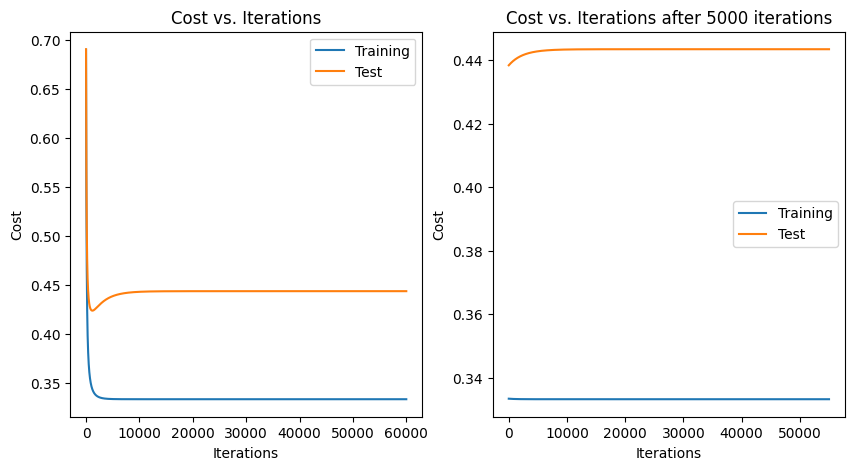

In [1193]:
# putting the learning curve to show the overfitting issue of the model
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(J_history, label='Training')
axs[0].plot(test_J_history, label='Test')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Cost')
axs[0].set_title('Cost vs. Iterations')
axs[0].legend()

axs[1].plot(J_history[5000:], label='Training')
axs[1].plot(test_J_history[5000:], label='Test')
axs[1].set_xlabel('Iterations')
axs[1].set_ylabel('Cost')
axs[1].set_title('Cost vs. Iterations after 5000 iterations')
axs[1].legend()

plt.show()

## Task 3: Regularization Analysis - Finding the Optimal λ Value **(20 points)**

`lambda_reg` controls the strength of the regularization applied to the model.  
- When `lambda_reg` is set to **zero**, regularization is effectively turned off.  
- As `lambda_reg` increases, the penalty for large weights becomes more significant, helping to **reduce overfitting**.  



### 🔧 Task Instructions
- Experiment with different values of `lambda_reg` in the set **[0.0, 0.01, 0.03, 0.1, 0.3]**.  
- Plot the **learning curves** for both the training and test sets on the same figure to visualize the impact of each value.  
- Determine which value of `lambda_reg` yields the **best performance** on this dataset.  
- Report the performance (accuracy, precision, recall) using the best value of:  
  - **Accuracy**  
  - **Precision**  
  - **Recall**  



**Hyperparameters for this task**:  
- `learning_rate = 0.005`  
- `num_iterations = 1200`  


In [1194]:
lambdas = [0.0, 0.01, 0.03, 0.1, 0.3] #lambda possibilities
#other hyperparameters
alhpa = 0.005
num_iters = 1200

#create object to store outputs
results = {}

#perform gradient descent for each lambda possibility
for lambda_val in lambdas:
    print(f"Training with lambda = {lambda_val}")
    w_init = np.zeros(n)
    w_trained, train_J_hist, test_J_hist = gradient_descent_logistic_ridge(X_train_scaled_ones, y_train, X_test_scaled_ones, y_test, w_init, alpha, num_iters, lambda_val)
    results[lambda_val] = {
        'w': w_trained,
        'train_J_history': train_J_hist,
        'test_J_history': test_J_hist
    }

Training with lambda = 0.0
For iteration 1/1200, the training cost is 0.6896626911943072.
For iteration 1/1200, the test cost is 0.6902435875458368.
Training with lambda = 0.01
For iteration 1/1200, the training cost is 0.6896626919138368.
For iteration 1/1200, the test cost is 0.6902435904003639.
Training with lambda = 0.03
For iteration 1/1200, the training cost is 0.6896626933528959.
For iteration 1/1200, the test cost is 0.690243596109418.
Training with lambda = 0.1
For iteration 1/1200, the training cost is 0.6896626983896027.
For iteration 1/1200, the test cost is 0.6902436160911072.
Training with lambda = 0.3
For iteration 1/1200, the training cost is 0.6896627127801935.
For iteration 1/1200, the test cost is 0.690243673181648.


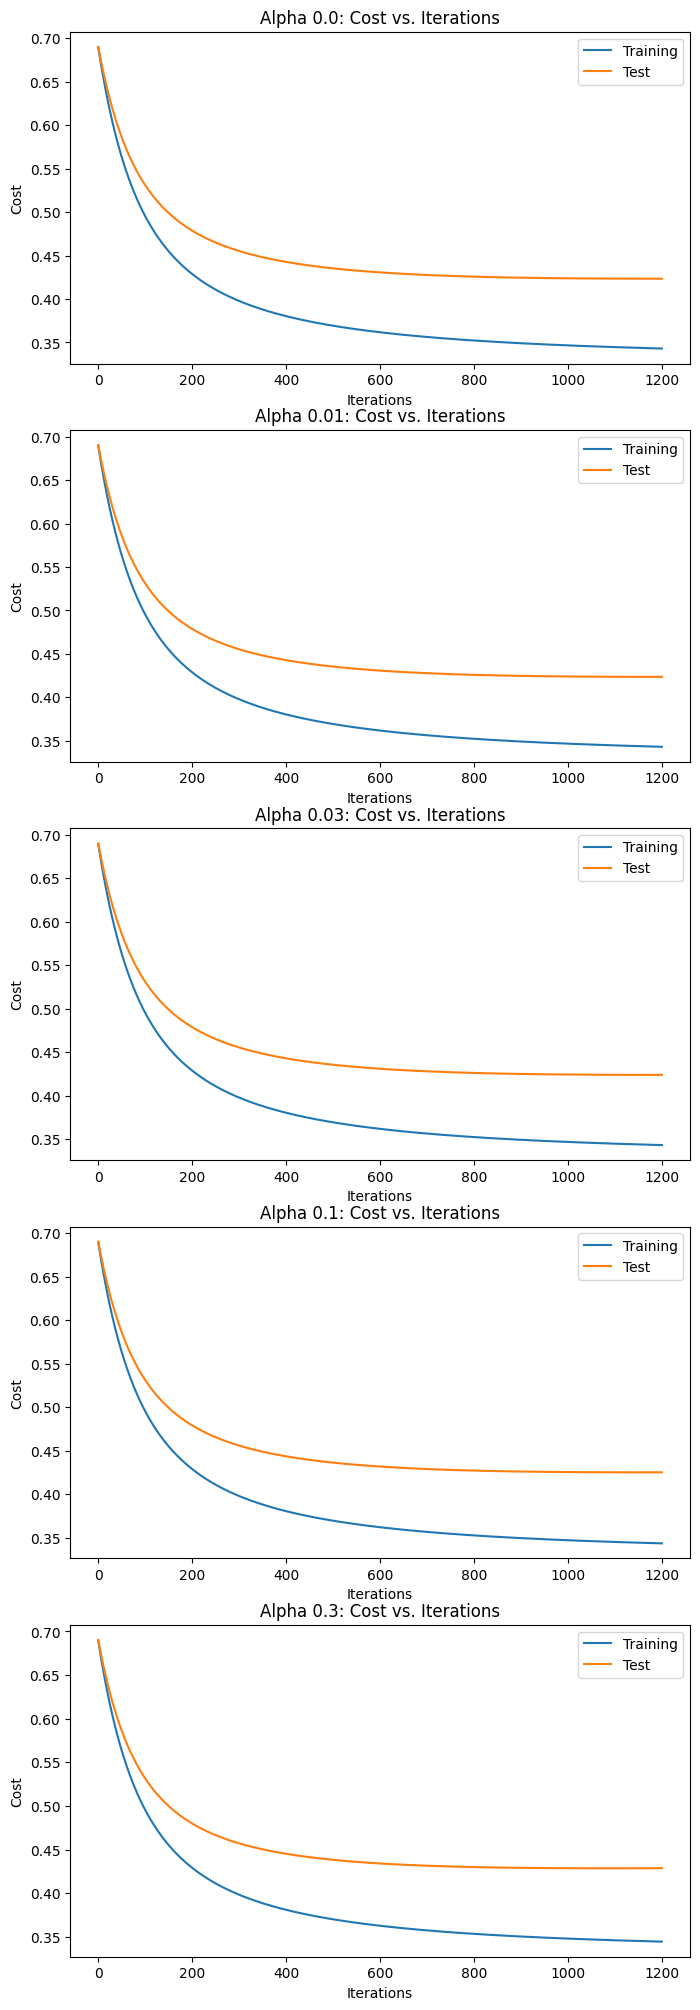

In [1195]:
#plot cost curves for each value of lambda
fig, axs = plt.subplots(5, 1, figsize=(8, 25))
axs[0].plot(results[0.0]['train_J_history'], label='Training')
axs[0].plot(results[0.0]['test_J_history'], label='Test')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Cost')
axs[0].set_title('Alpha 0.0: Cost vs. Iterations')
axs[0].legend()

axs[1].plot(results[0.01]['train_J_history'], label='Training')
axs[1].plot(results[0.01]['test_J_history'], label='Test')
axs[1].set_xlabel('Iterations')
axs[1].set_ylabel('Cost')
axs[1].set_title('Alpha 0.01: Cost vs. Iterations')
axs[1].legend()

axs[2].plot(results[0.03]['train_J_history'], label='Training')
axs[2].plot(results[0.03]['test_J_history'], label='Test')
axs[2].set_xlabel('Iterations')
axs[2].set_ylabel('Cost')
axs[2].set_title('Alpha 0.03: Cost vs. Iterations')
axs[2].legend()

axs[3].plot(results[0.1]['train_J_history'], label='Training')
axs[3].plot(results[0.1]['test_J_history'], label='Test')
axs[3].set_xlabel('Iterations')
axs[3].set_ylabel('Cost')
axs[3].set_title('Alpha 0.1: Cost vs. Iterations')
axs[3].legend()

axs[4].plot(results[0.3]['train_J_history'], label='Training')
axs[4].plot(results[0.3]['test_J_history'], label='Test')
axs[4].set_xlabel('Iterations')
axs[4].set_ylabel('Cost')
axs[4].set_title('Alpha 0.3: Cost vs. Iterations')
axs[4].legend()

In [1196]:
#create functions to obtain predictions in order to get scores
def predict_logistic_ridge(X, w): #raw predictions
    z = X @ w
    z_safe = np.clip(z, -500, 500)
    predictions = 1 / (1 + np.exp(-z_safe))
    return predictions


def predict_binary(X, w, threshold=0.5): #classified predictions
    probabilities = predict_logistic_ridge(X, w)
    return (probabilities >= threshold).astype(int)

In [1197]:
#store predictions
predictions = {}

#obtain predictions for all lambdas
for lambda_val in lambdas:
    w = results[lambda_val]['w']
    preds = predict_binary(X_test_scaled_ones, w, threshold=0.5)
    predictions[lambda_val] = preds

In [1198]:
#calculate scores for all lambdas
for value in lambdas:
    preds = predictions[value]
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    print(f"Lambda: {value} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

Lambda: 0.0 - Accuracy: 0.8361, Precision: 0.8205, Recall: 0.9143
Lambda: 0.01 - Accuracy: 0.8361, Precision: 0.8205, Recall: 0.9143
Lambda: 0.03 - Accuracy: 0.8361, Precision: 0.8205, Recall: 0.9143
Lambda: 0.1 - Accuracy: 0.8361, Precision: 0.8205, Recall: 0.9143
Lambda: 0.3 - Accuracy: 0.8361, Precision: 0.8205, Recall: 0.9143


We can see here that all values of lambda produce the same scores, indicating that this is a pretty clean, simple dataset that is not affected by regularization. 

## Task 4: Custom vs. scikit-learn — Comprehensive Benchmark Analysis **(20 points)**

- Use the **`LogisticRegression`** model from **scikit-learn** to re-evaluate the dataset while keeping the same (or as similar as possible) hyperparameter settings for a **fair comparison**.  
- Report the performance using the **same evaluation metrics** as previously used.  
- Compare the results to your **custom implementation**. Analyze whether scikit-learn’s built-in logistic regression achieves similar, better, or worse performance.  
- Explain the potential reasons for any differences you observe. 



In [1199]:
#LogisticRegression model
lr_model = LogisticRegression(penalty='l2', C=1/0.005, max_iter=1200)
lr_model.fit(X_train_scaled_ones, y_train)
train_predictions = lr_model.predict(X_train_scaled_ones)
test_predictions = lr_model.predict(X_test_scaled_ones)

In [1200]:
#obtain train metrics
train_accuracy = accuracy_score(y_train, train_predictions)
train_precision = precision_score(y_train, train_predictions)
train_recall = recall_score(y_train, train_predictions)
print(f"Train metrics - Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")

#obtain test metrics
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
print(f"Test metrics - Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

Train metrics - Accuracy: 0.8512, Precision: 0.8406, Recall: 0.8923
Test metrics - Accuracy: 0.8197, Precision: 0.8000, Recall: 0.9143


From these results, we see that the sklearn model performs the same according to the recall metric, but the custom model performs better according to the other two metrics. This suggests that the setup of the sklearn model is doing better at classifying true positives. It could be that sklearn is tailored to classifying as many positives correctly as possible, while the custom model more wholistically improves based on cost, which causes it to do better overall, but the same at recall. 

## Task 5: Understanding Convergence - The `tol` Parameter Deep Dive **(15 points)**

In many models that use gradient descent–based optimization, `tol` is a key hyperparameter.  
In this task, you will explore its role using **logistic regression**.

### **Understanding the Tolerance Parameter**
The `tol` parameter in sklearn's LogisticRegression controls **when to stop the optimization process**:

- **What it measures**: Maximum change in the optimization objective between iterations
- **Stopping criterion**: Training stops when improvement falls below this threshold
- **Trade-off**: Tighter tolerance (smaller values) → more iterations → potentially better convergence
- **Efficiency**: Looser tolerance (larger values) → fewer iterations → faster training but potentially suboptimal results

### **Mathematical Context**
For solver convergence, sklearn typically uses:
$$|\nabla J(\mathbf{w}^{(t)}) - \nabla J(\mathbf{w}^{(t-1)})| < \text{tol}$$
Or for objective function change:
$$|J(\mathbf{w}^{(t)}) - J(\mathbf{w}^{(t-1)})| < \text{tol}$$


### **Expected Insights**

Experiment with the following `tol` values to explore their impact on model convergence, training speed, and performance:

**Typical Patterns You Should Observe:**
- **Tighter tolerance (`1e-6`, `1e-7`)** → Training is slower but may yield slightly better performance.  
- **Moderate tolerance (`1e-4`, `1e-5`)** → A good balance between speed and accuracy (close to scikit-learn’s default).  
- **Loose tolerance (`1e-1`, `1e-2`)** → Faster training but may stop too early, leading to suboptimal results.  
- **Performance plateau** → Beyond a certain level of tightness, further decreasing tolerance does not yield meaningful gains.  
- **Convergence issues** → Extremely tight tolerance may require more iterations than allowed, preventing proper convergence.  


### ✅ **Success Criteria**
- [ ] Systematic testing across tolerance range (8+ values)
- [ ] Comprehensive performance and efficiency metrics
- [ ] Professional visualization with multiple perspectives
- [ ] Clear identification of trade-offs and recommendations
- [ ] Evidence-based analysis of sklearn's default choice

In [1201]:
#create tol range
tols = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

#storage objects
training_time_list = []
train_accuracy_list = []
test_accuracy_list = []
test_precision_list = []
train_precision_list = []
test_recall_list = []
train_recall_list = []

for tol in tols:

    lr_model = LogisticRegression(penalty='l2', C=1/0.005, tol=tol, max_iter=1200)

    #calculate training time
    start_time = time.time()
    lr_model.fit(X_train_scaled_ones, y_train)
    end_time = time.time()
    training_time_list.append(end_time - start_time)

    #obtain predictions
    train_predictions = lr_model.predict(X_train_scaled_ones)
    test_predictions = lr_model.predict(X_test_scaled_ones)
    
    #obtain train metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    train_precision = precision_score(y_train, train_predictions)
    train_recall = recall_score(y_train, train_predictions)
    
    #obtain test metrics
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions)
    test_recall = recall_score(y_test, test_predictions)
    
    #add to storage objects
    train_accuracy_list.append(train_accuracy)
    train_precision_list.append(train_precision)
    train_recall_list.append(train_recall)
    test_accuracy_list.append(test_accuracy)
    test_precision_list.append(test_precision)
    test_recall_list.append(test_recall)

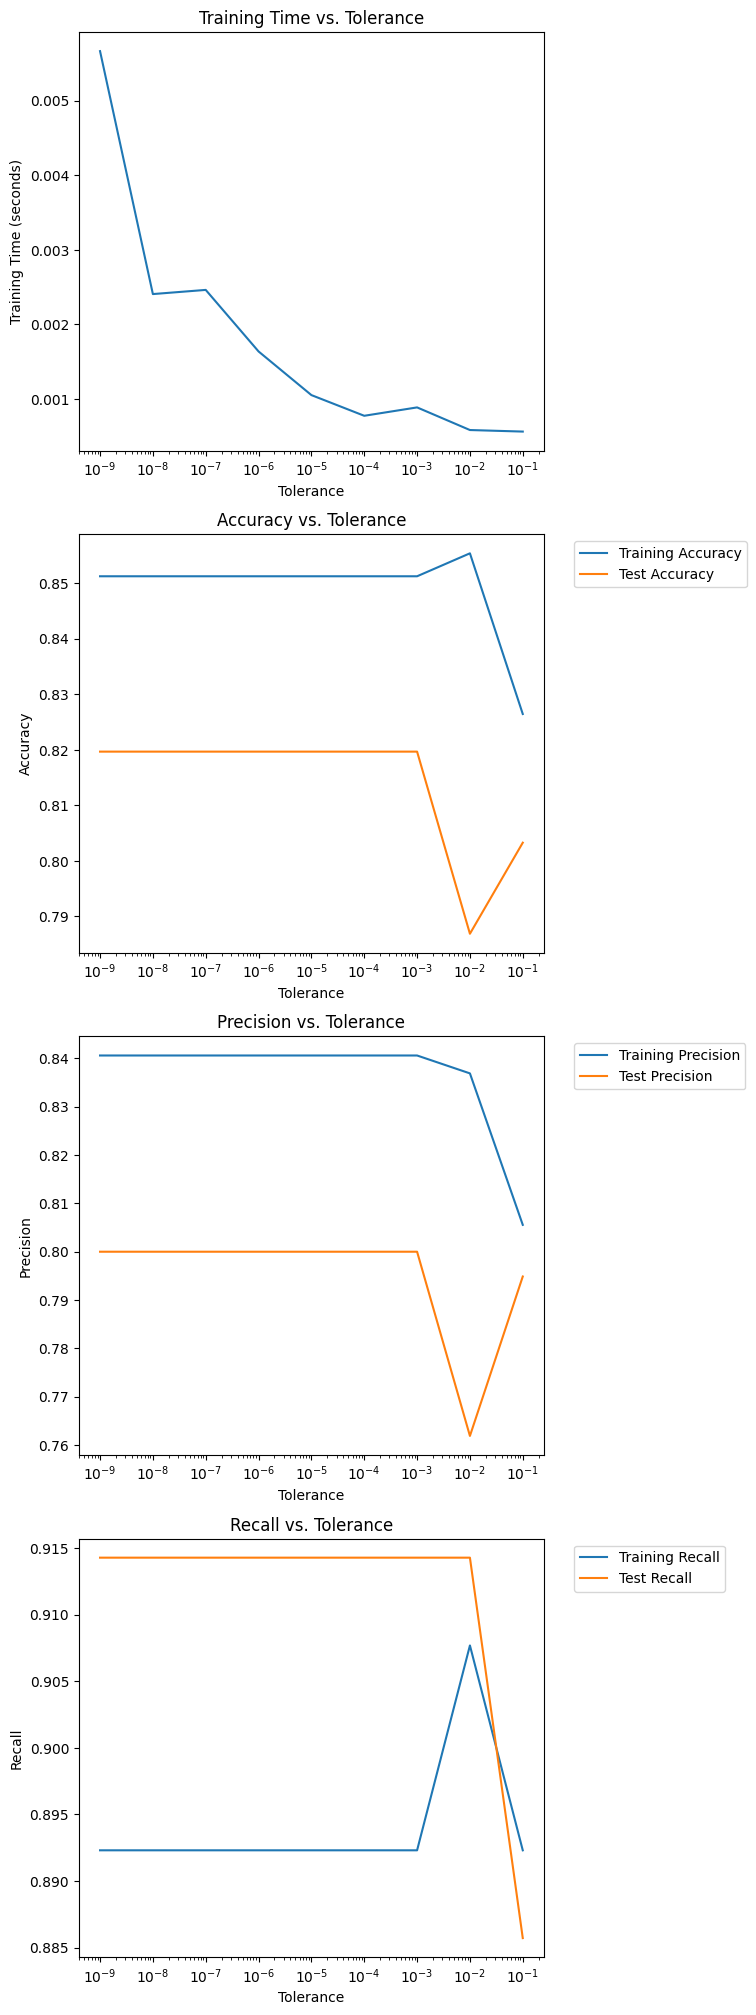

In [1202]:
#plots of training time differences and metric differences
fig, axs = plt.subplots(4, 1, figsize=(6, 25))

axs[0].plot(tols, training_time_list)
axs[0].set_title('Training Time vs. Tolerance')
axs[0].set_xlabel('Tolerance')
axs[0].set_ylabel('Training Time (seconds)')
axs[0].set_xscale('log')

axs[1].plot(tols, train_accuracy_list, label='Training Accuracy')
axs[1].plot(tols, test_accuracy_list, label='Test Accuracy')
axs[1].set_title('Accuracy vs. Tolerance')
axs[1].set_xlabel('Tolerance')
axs[1].set_ylabel('Accuracy')
axs[1].set_xscale('log')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

axs[2].plot(tols, train_precision_list, label='Training Precision')
axs[2].plot(tols, test_precision_list, label='Test Precision')
axs[2].set_title('Precision vs. Tolerance')
axs[2].set_xlabel('Tolerance')
axs[2].set_ylabel('Precision')
axs[2].set_xscale('log')
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

axs[3].plot(tols, train_recall_list, label='Training Recall')
axs[3].plot(tols, test_recall_list, label='Test Recall')
axs[3].set_title('Recall vs. Tolerance')
axs[3].set_xlabel('Tolerance')
axs[3].set_ylabel('Recall')
axs[3].set_xscale('log')
axs[3].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

We can see from the above plots that there is definitely a tradeoff between training time and performance. As the tolerace increases, the training time decreases greatly, however, the performance metrics also decrease or become much more inconsistent. The default value of tol for sklearn is 1e-4, which seems to be a good balance when looking at the plots above. Performance seems to stay pretty constant on both training and test sets until tol reaches about 1e-3, and then it drops off. This indiacate to me that the default value is a good choice, because it balances between longer training times and good performance, and stays in a consistent performance range. 

## Bonus Task: Implementing `tol` in Your L2 Gradient Descent (15 points)

*This is a bonus task, feel free to skip this task*

To make your **custom L2-regularized gradient descent** implementation comparable with scikit-learn’s `LogisticRegression`, you should add the `tol` parameter as a **stopping criterion**.  

### ✅ Instructions:
1. During each iteration of gradient descent, compute the **change in cost (loss)** between the current and previous step.  
2. If the change is **smaller than `tol`**, stop the training loop early.  
3. Use the same tolerance values (`tol`) as in scikit-learn for a fair comparison.  
4. Report:  
   - The number of iterations completed before convergence.  
   - Final training and test performance metrics.  

## Task 6: Summarize your findings below **(5 points)**

In [1203]:
#new gradient descent function 
def gradient_descent_logistic_ridge_with_tol(X_train, y_train, X_test, y_test, w_in, alpha, num_iters, lambda_reg, tol):

    #create storage objects
    J_history = []
    test_J_history = []
    number_iters_completed = []

    #copy w
    w = copy.deepcopy(w_in)

    for i in range(num_iters):
        gradient = compute_gradient_logistic_ridge(X_train, y_train, w, lambda_reg) #compute gradient
        w = w - (alpha*gradient) #update gradient
        cost = compute_cost_logistic_ridge(X_train, y_train, w, lambda_reg) #compute train cost
        J_history.append(cost)
        test_cost = compute_cost_logistic_ridge(X_test, y_test, w, lambda_reg) #compute test cost
        test_J_history.append(test_cost)
        cost_change = np.abs(J_history[-1] - J_history[-2]) if i > 0 else np.inf #calculate cost change from last time
        if cost_change < tol: #stop if change less than tol
            number_iters_completed.append(i+1) #and update total number of iters for this i
            print(f"Convergence reached at iteration {i+1} with cost change {cost_change}.")
            break
        if i % 5000 == 0:
            print(f"For iteration {i+1}/{num_iters}, the training cost is {cost}.")
            print(f"For iteration {i+1}/{num_iters}, the test cost is {test_cost}.")
        if i == num_iters - 1: #if never breaks, add total number of iters to storage object
            number_iters_completed.append(num_iters)
    
    return w, J_history, test_J_history, number_iters_completed

In [1204]:
#define hyperparameters
lambda_l2 = 0.004
alhpa = 0.005
num_iters = 20000
tols = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1] #tol range

#storage objects
number_iters_completed_list = []
results = {}

#for each tol, perform gradient descent with new function
for tol in tols:
    print(f"Training with tol = {tol}")
    w_init = np.zeros(n)
    w_trained, train_J_hist, test_J_hist, number_iters_completed = gradient_descent_logistic_ridge_with_tol(X_train_scaled_ones, y_train, X_test_scaled_ones, y_test, w_init, alpha, num_iters, lambda_val, tol)
    number_iters_completed_list.append(number_iters_completed)
    results[tol] = {
        'w': w_trained,
        'train_J_history': train_J_hist,
        'test_J_history': test_J_hist
    }

Training with tol = 1e-09
For iteration 1/20000, the training cost is 0.6896627127801935.
For iteration 1/20000, the test cost is 0.690243673181648.
For iteration 5001/20000, the training cost is 0.3356684572357103.
For iteration 5001/20000, the test cost is 0.44574092811640287.
For iteration 10001/20000, the training cost is 0.3355430764050238.
For iteration 10001/20000, the test cost is 0.449906142172222.
Convergence reached at iteration 10365 with cost change 9.999636674251633e-10.
Training with tol = 1e-08
For iteration 1/20000, the training cost is 0.6896627127801935.
For iteration 1/20000, the test cost is 0.690243673181648.
For iteration 5001/20000, the training cost is 0.3356684572357103.
For iteration 5001/20000, the test cost is 0.44574092811640287.
Convergence reached at iteration 7661 with cost change 9.993648464323712e-09.
Training with tol = 1e-07
For iteration 1/20000, the training cost is 0.6896627127801935.
For iteration 1/20000, the test cost is 0.690243673181648.
For

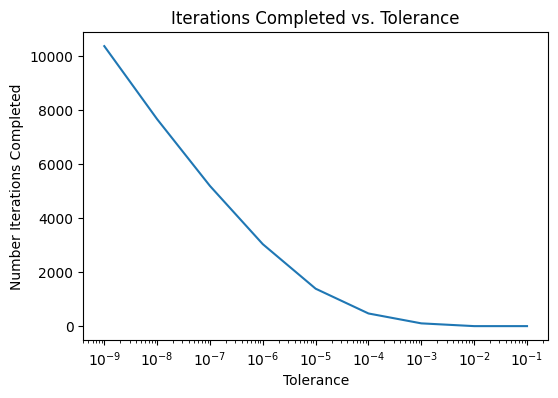

In [1205]:
#visualize how many iterations were completed as tol changed
fig, axs = plt.subplots(1, 1, figsize=(6,4))

axs.plot(tols, number_iters_completed_list)
axs.set_title('Iterations Completed vs. Tolerance')
axs.set_xlabel('Tolerance')
axs.set_ylabel('Number Iterations Completed')
axs.set_xscale('log')

In [1206]:
#get predictions for model with each tol
predictions = {}

for tol in tols:
    w = results[tol]['w']
    preds = predict_binary(X_test_scaled_ones, w, threshold=0.5)
    predictions[tol] = preds

In [1207]:
#calculate metrics for each tol
for tol in tols:
    preds = predictions[tol]
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    print(f"tol: {tol} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

tol: 1e-09 - Accuracy: 0.8197, Precision: 0.8000, Recall: 0.9143
tol: 1e-08 - Accuracy: 0.8197, Precision: 0.8000, Recall: 0.9143
tol: 1e-07 - Accuracy: 0.8197, Precision: 0.8000, Recall: 0.9143
tol: 1e-06 - Accuracy: 0.8197, Precision: 0.8000, Recall: 0.9143
tol: 1e-05 - Accuracy: 0.8361, Precision: 0.8205, Recall: 0.9143
tol: 0.0001 - Accuracy: 0.8525, Precision: 0.8421, Recall: 0.9143
tol: 0.001 - Accuracy: 0.8197, Precision: 0.8158, Recall: 0.8857
tol: 0.01 - Accuracy: 0.8033, Precision: 0.8108, Recall: 0.8571
tol: 0.1 - Accuracy: 0.8033, Precision: 0.8108, Recall: 0.8571


We see that as tol increases, our metrics generally decrease or stay the same, and fewer iterations are performed. This indicates that when we use too large of a tol value, we are not reaching enough iterations to make as accurate of predictions. 

## AI Use Disclosure **(5 pts)**

In **1–3 short paragraphs**, clearly state whether **generative AI tools** were used to complete any part of this assignment.

- If **no AI was used**, write:  
  *“I did not use generative AI tools on this assignment.”*  

- If **AI was used**, you must specify:  
  1. **Tool(s)** used (e.g., ChatGPT, GitHub Copilot, Claude, etc.)  
  2. **How** they were used (e.g., idea generation, debugging, code suggestions, writing help)  
  3. **Where** they influenced your work (which questions/sections)  
  4. **Edits & verification** you made (how you checked correctness, what you modified)  

### AI Use Template
- **Used AI?** Yes / No  
- **Tool(s):**  
- **Purpose / How used (1–3 sentences):**  
- **Scope (which questions/sections):**  
- **Edits & verification (what you changed and how you checked correctness):**  

> **Example (for illustration only):**  
> - Used AI? Yes  
> - Tools: ChatGPT (free), GitHub Copilot  
> - How used: Asked for a pandas snippet to impute missing values and for a seaborn example.  
> - Scope: Q1(b) imputation, Q2(a) first draft of bar chart code.  
> - Edits & verification: Rewrote code to use `groupby().transform('median')`; validated results by comparing summary stats; added axis labels manually.  

**Grading (5 points):**  
- **5 points** = complete, specific, and honest (tools named, usage described clearly)  
- **3–4 points** = vague or missing some details  
- **1–2 points** = minimal effort or very unclear  
- **0 points** = missing or misleading disclosure  


### AI Use Disclosure
- **Used AI?** Yes 
- **Tool(s):**  Claude AI
- **Purpose / How used (1–3 sentences):**  Asked for support to debug syntax errors and large warning messages. 
- **Scope (which questions/sections):**  Used to troubleshoot my functions in Task 1 when I tried running them in Task 2 and got errors or warnings. 
- **Edits & verification (what you changed and how you checked correctness):**  In cost function, changed z calculation from z = w.T @ X to z = X @ w to fix syntax errors. I also updated my cost function because I was missing a parentheses around (2*m) which was causing my costs to deceivingly increase over time. Finally, I adjusted how I was extracting column names when using my OneHotEncoder to create a dataframe with the outputs before trying to append them to my X dataframes. 